# JAE: Joint Autoencoder for Neural Signal Denoising

## Comprehensive Demo & Experiments

This notebook demonstrates the JAE package for denoising high-dimensional neural signals. We'll compare:
- **JAE1** (Original 2021): Fixed 50/50 channel split, fully-connected layers
- **JAE2** (Modernized): N-way multi-view, U-Net architecture, VICReg loss
- **PCA** (Baseline): Linear denoising

**Author**: Ege Altan  
**Based on**: Altan et al. (2021), PLOS Computational Biology


## 1. Setup & Installation

First, install the package:
```bash
pip install jae  # or: pip install -e . for development
```


In [11]:
# Import necessary libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add package to path if running from source
sys.path.insert(0, '../src')

from jae import (
    JAE,
    generate_data_scenarios,
    calculate_snr,
    calculate_r2_score,
    run_pca_baseline,
    plot_signals,
    plot_multichannel_signals,
    plot_snr_comparison,
    plot_channel_snr_distribution,
    plot_training_history,
    plot_regime_changes,
    set_seed
)

# ═══════════════════════════════════════════════════════════════════════════
# SET GLOBAL SEED FOR FULL REPRODUCIBILITY
# ═══════════════════════════════════════════════════════════════════════════
# This sets seeds for: numpy, torch, CUDA, and disables cudnn non-determinism
GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
print(f"✓ Global seed set to {GLOBAL_SEED} for reproducibility\n")

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


✓ Global seed set to 42 for reproducibility

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
GPU Memory: 24.0 GB


## 2. Quick Start: 5 Lines of Code

The simplest way to use JAE for neural signal denoising:


In [ ]:
# Generate synthetic noisy neural data
data = generate_data_scenarios('easy', n_samples=200, seed=GLOBAL_SEED)
noisy_data = data['noisy']

# Create model (JAE2 by default, auto-detects parameters)
model = JAE(latent_dim=12, use_gpu=True)

# Train and denoise in one line
clean_data = model.fit_denoise(noisy_data, epochs=50, batch_size=32)

print(f"✓ Denoised {noisy_data.shape} successfully!")
print(f"  Input SNR: {data['info']['snr_db']:.2f} dB")
print(f"  Output SNR: {calculate_snr(data['clean'], torch.from_numpy(clean_data)):.2f} dB")


Using device: cuda (NVIDIA GeForce RTX 4090)
GPU Memory: 24.0 GB

Initialized JAE2 model:
  Input channels: 96
  Latent dimension: 12
  Number of networks: 5
  Subsample fraction: 0.8

Training JAE2 model...
  Epochs: 50
  Batch size: 32
  Learning rate: 0.0003
  Training samples: 200
Epoch [1/50], Train Loss: 2.5724
Epoch [5/50], Train Loss: 2.3333
Epoch [10/50], Train Loss: 2.3239
Epoch [15/50], Train Loss: 2.3135
Epoch [20/50], Train Loss: 2.2952


## 3. Data Generation & Scenarios

We generate 5 different scenarios to demonstrate when JAE2 outperforms JAE1:

1. **Easy**: Smooth sinusoids, low noise → Both methods similar
2. **Transients**: Sharp spikes → JAE2 (U-Net) advantage
3. **Heterogeneous**: Varied channel noise → JAE2 (multi-view) advantage
4. **Non-stationary**: Regime changes → JAE2 (temporal) advantage
5. **High Noise**: Extreme challenge for both


In [ ]:
# Generate all scenarios
scenarios = ['easy', 'transients', 'heterogeneous', 'nonstationary', 'high_noise']
n_samples = 400  # Enough data for training

datasets = {}
for scenario in scenarios:
    print(f"\nGenerating '{scenario}' scenario...")
    datasets[scenario] = generate_data_scenarios(scenario, n_samples=n_samples, seed=GLOBAL_SEED)
    info = datasets[scenario]['info']
    print(f"  ✓ SNR: {info['snr_db']:.2f} dB")
    print(f"  ✓ {info['description']}")



Generating 'easy' scenario...
  ✓ SNR: 3.12 dB
  ✓ Smooth sinusoids, low noise

Generating 'transients' scenario...
  ✓ SNR: 6.22 dB
  ✓ Sharp transients (spikes), favors U-Net

Generating 'heterogeneous' scenario...
  ✓ SNR: 11.45 dB
  ✓ Heterogeneous noise across channels, favors multi-view

Generating 'nonstationary' scenario...
  ✓ SNR: 8.05 dB
  ✓ Non-stationary dynamics, favors temporal convolutions

Generating 'high_noise' scenario...
  ✓ SNR: -0.76 dB
  ✓ High noise level, challenging for both


### 3.1 Visualize Example Signals from Each Scenario


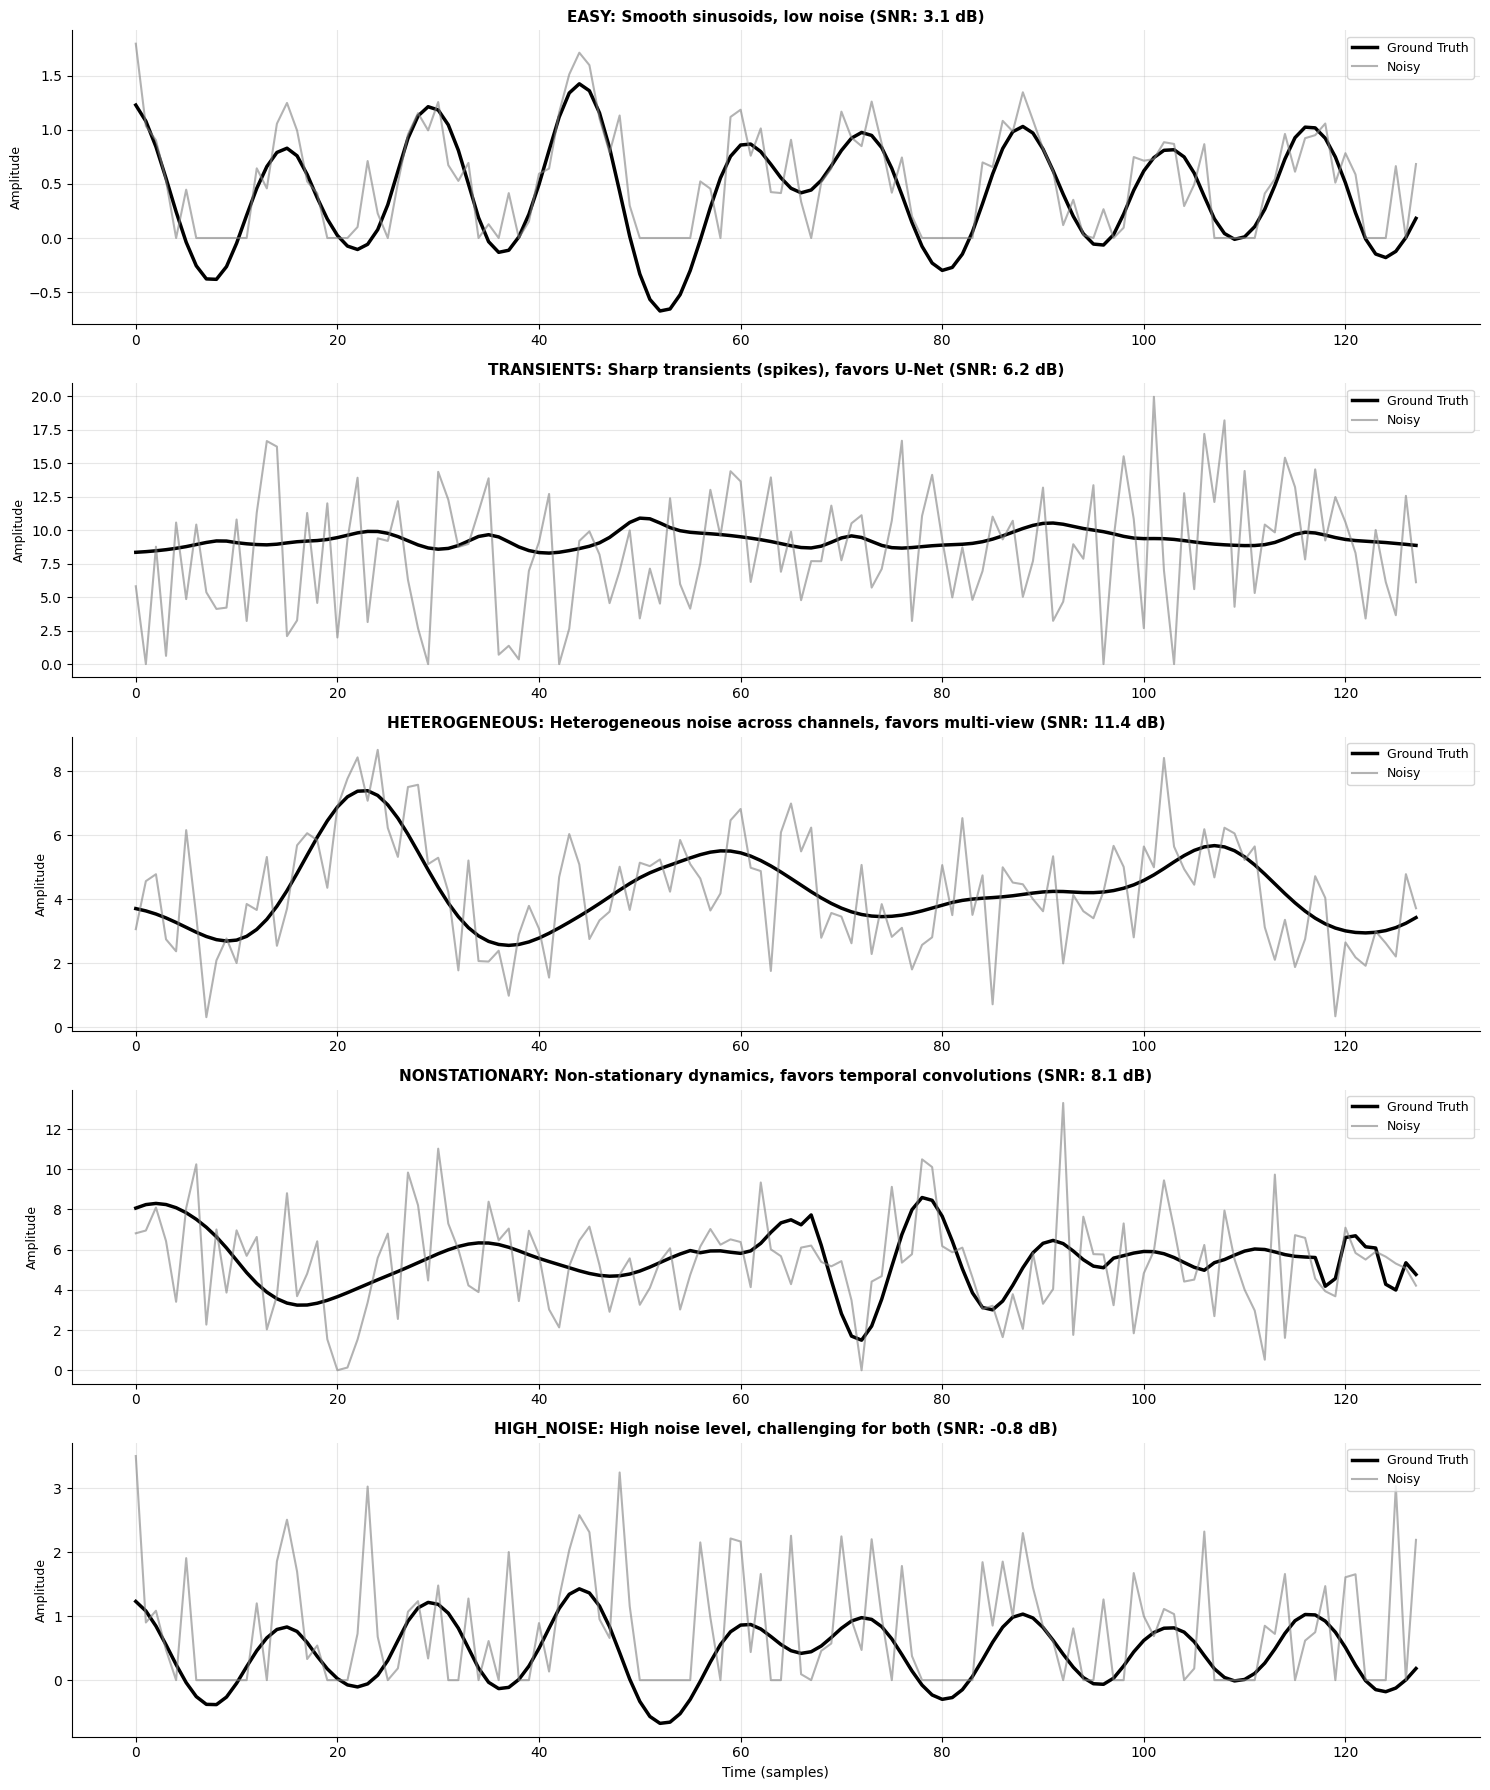

In [ ]:
# Plot example signals from each scenario
fig, axes = plt.subplots(5, 1, figsize=(15, 18))

for idx, scenario in enumerate(scenarios):
    data = datasets[scenario]
    clean = data['clean']
    noisy = data['noisy']
    
    # Extract one channel from one sample
    sample_idx, channel_idx = 0, 5
    t = np.arange(clean.shape[2])
    
    axes[idx].plot(t, clean[sample_idx, channel_idx, :].numpy(), 
                   label='Ground Truth', color='black', linewidth=2.5, alpha=1.0)
    axes[idx].plot(t, noisy[sample_idx, channel_idx, :].numpy(), 
                   label='Noisy', color='gray', linewidth=1.5, alpha=0.6)
    
    axes[idx].set_title(f"{scenario.upper()}: {data['info']['description']} (SNR: {data['info']['snr_db']:.1f} dB)",
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Amplitude', fontsize=9)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

axes[-1].set_xlabel('Time (samples)', fontsize=10)
plt.tight_layout()
plt.show()


### 3.2 Multi-channel View (Transients Scenario)


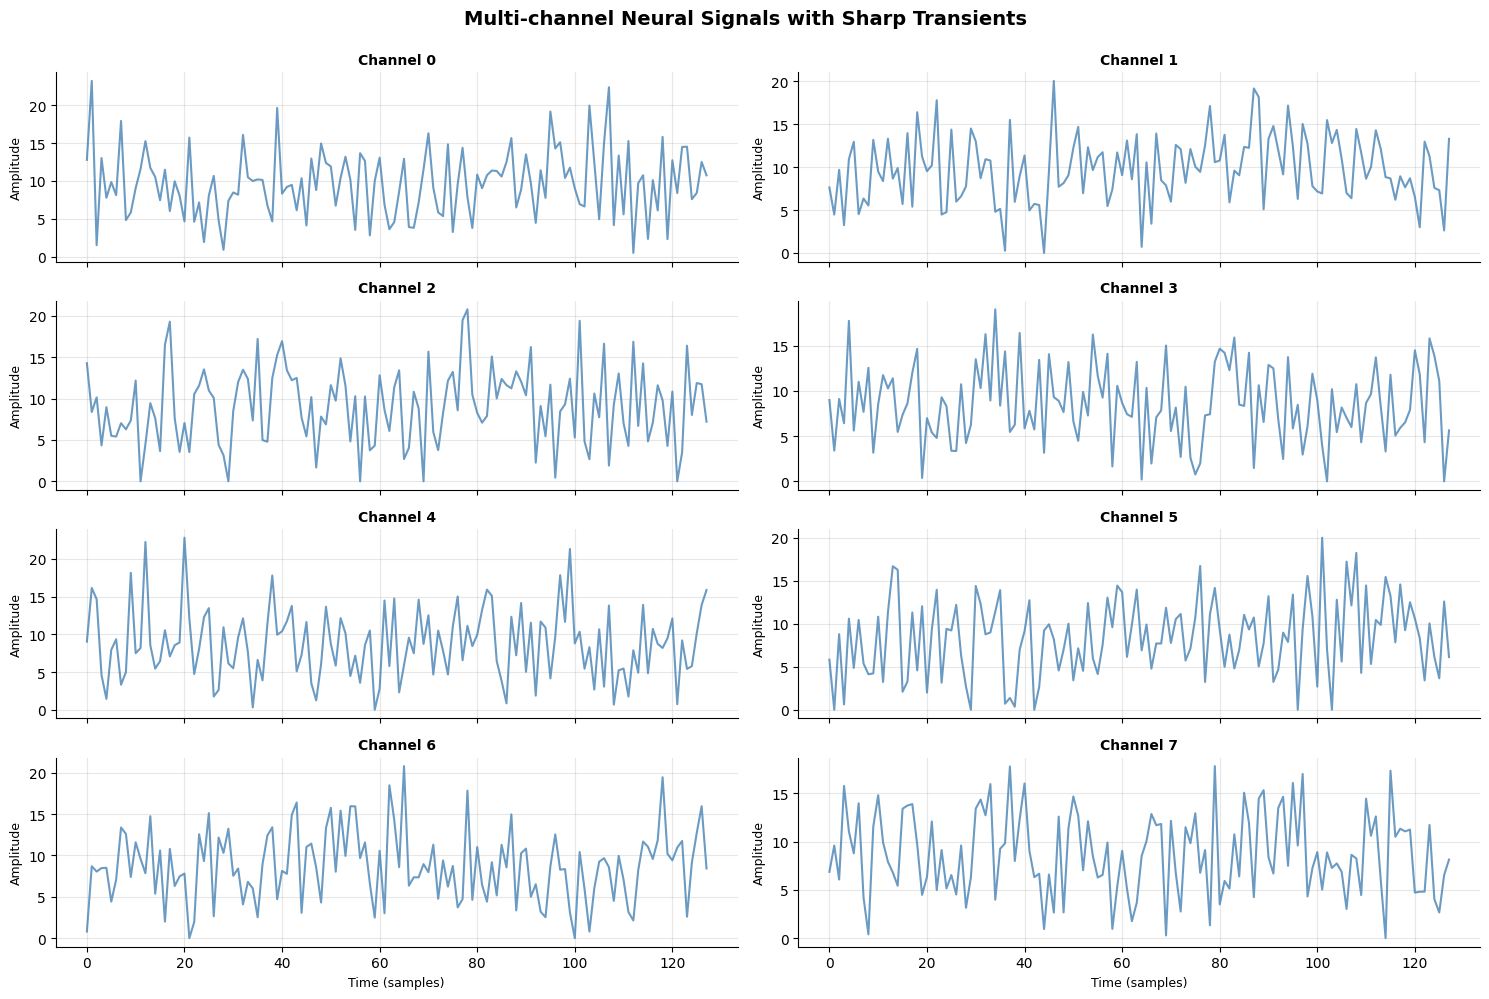

In [ ]:
# Show multi-channel view for 'transients' scenario
plot_multichannel_signals(
    datasets['transients']['noisy'],
    n_channels_to_plot=8,
    sample_idx=0,
    title='Multi-channel Neural Signals with Sharp Transients'
)
plt.show()


## 4. Training & Comparison: JAE1 vs JAE2 vs PCA

Now we'll train both models and compare against PCA baseline. This may take a few minutes depending on your hardware.


In [ ]:
# Training configuration
LATENT_DIM = 12
EPOCHS = 60  # Reduce for faster demo, increase for better results
BATCH_SIZE = 32

# Store results
results = {scenario: {} for scenario in scenarios}

print("Starting training across all scenarios...")
print("This will take a few minutes on GPU, longer on CPU.")


Starting training across all scenarios...
This will take a few minutes on GPU, longer on CPU.


In [ ]:
# Train on each scenario
for scenario in scenarios:
    print(f"\n{'='*70}")
    print(f"SCENARIO: {scenario.upper()}")
    print(f"{'='*70}")
    
    data = datasets[scenario]
    clean = data['clean']
    noisy = data['noisy']
    
    # Baseline SNR
    baseline_snr = calculate_snr(clean, noisy)
    print(f"\n📊 Baseline (Noisy): SNR={baseline_snr:.2f} dB")
    
    # PCA Baseline
    print("\n🟣 Running PCA baseline...")
    pca_denoised = run_pca_baseline(noisy, latent_dim=LATENT_DIM)
    pca_snr = calculate_snr(clean, pca_denoised)
    print(f"   ✓ PCA: SNR={pca_snr:.2f} dB (+{pca_snr-baseline_snr:.2f})")
    
    # JAE1 (Original)
    print("\n🔵 Training JAE1 (Original)...")
    jae1 = JAE(model_type='jae1', latent_dim=LATENT_DIM, use_gpu=True, verbose=False)
    jae1.fit(noisy.numpy(), epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=True)
    jae1_denoised = torch.from_numpy(jae1.denoise(noisy.numpy()))
    jae1_snr = calculate_snr(clean, jae1_denoised)
    print(f"   ✓ JAE1: SNR={jae1_snr:.2f} dB (+{jae1_snr-baseline_snr:.2f})")
    
    # JAE2 (Modernized)
    print("\n🔴 Training JAE2 (Modernized)...")
    jae2 = JAE(model_type='jae2', latent_dim=LATENT_DIM, num_networks=5, use_gpu=True, verbose=False)
    jae2.fit(noisy.numpy(), epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=True)
    jae2_denoised = torch.from_numpy(jae2.denoise(noisy.numpy()))
    jae2_snr = calculate_snr(clean, jae2_denoised)
    print(f"   ✓ JAE2: SNR={jae2_snr:.2f} dB (+{jae2_snr-baseline_snr:.2f})")
    
    # Store results
    results[scenario] = {
        'clean': clean,
        'noisy': noisy,
        'pca': pca_denoised,
        'jae1': jae1_denoised,
        'jae2': jae2_denoised,
        'snrs': {
            'Baseline': baseline_snr,
            'PCA': pca_snr,
            'JAE1': jae1_snr,
            'JAE2': jae2_snr
        }
    }
    
    best_method = 'JAE2' if jae2_snr == max(pca_snr, jae1_snr, jae2_snr) else 'JAE1' if jae1_snr == max(pca_snr, jae1_snr, jae2_snr) else 'PCA'
    print(f"\n🏆 Best method: {best_method}")



SCENARIO: EASY

📊 Baseline (Noisy): SNR=3.12 dB

🟣 Running PCA baseline...
   ✓ PCA: SNR=3.43 dB (+0.31)

🔵 Training JAE1 (Original)...

Training JAE1 model...
  Epochs: 60
  Batch size: 32
  Learning rate: 0.001
  Training samples: 400
Epoch [1/60], Train Loss: 1.1632
Epoch [6/60], Train Loss: 0.6075
Epoch [12/60], Train Loss: 0.2846
Epoch [18/60], Train Loss: 0.2575
Epoch [24/60], Train Loss: 0.2436
Epoch [30/60], Train Loss: 0.2326
Epoch [36/60], Train Loss: 0.2231
Epoch [42/60], Train Loss: 0.2138
Epoch [48/60], Train Loss: 0.2056
Epoch [54/60], Train Loss: 0.1986
Epoch [60/60], Train Loss: 0.1855

Training complete!
   ✓ JAE1: SNR=3.09 dB (+-0.03)

🔴 Training JAE2 (Modernized)...

Training JAE2 model...
  Epochs: 60
  Batch size: 32
  Learning rate: 0.0003
  Training samples: 400
Epoch [1/60], Train Loss: 2.5848
Epoch [6/60], Train Loss: 2.2454
Epoch [12/60], Train Loss: 1.5824
Epoch [18/60], Train Loss: 1.4453
Epoch [24/60], Train Loss: 1.2432
Epoch [30/60], Train Loss: 1.2039
E

## 5. Results & Visualization

### 5.1 SNR Comparison Across All Scenarios


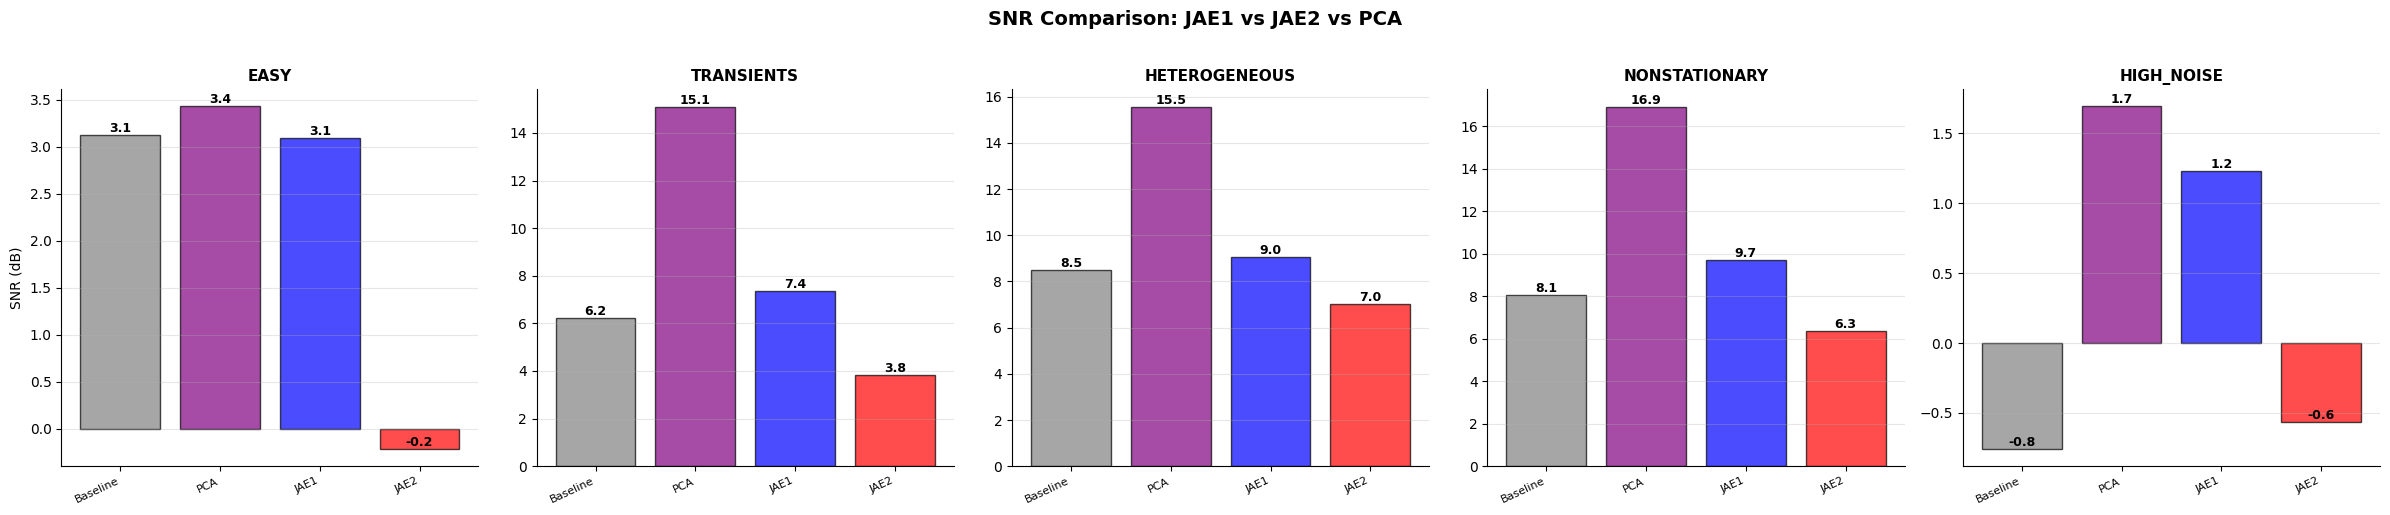

In [ ]:
# Create SNR comparison plots
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    snrs = results[scenario]['snrs']
    
    methods = list(snrs.keys())
    values = list(snrs.values())
    colors = ['gray', 'purple', 'blue', 'red']
    
    bars = ax.bar(methods, values, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{value:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(scenario.upper(), fontsize=11, fontweight='bold')
    ax.set_ylabel('SNR (dB)' if idx == 0 else '', fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right', fontsize=8)

fig.suptitle('SNR Comparison: JAE1 vs JAE2 vs PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 5.2 Visual Denoising Results

Let's visualize the actual denoising performance for the 'transients' scenario (where JAE2 should excel):


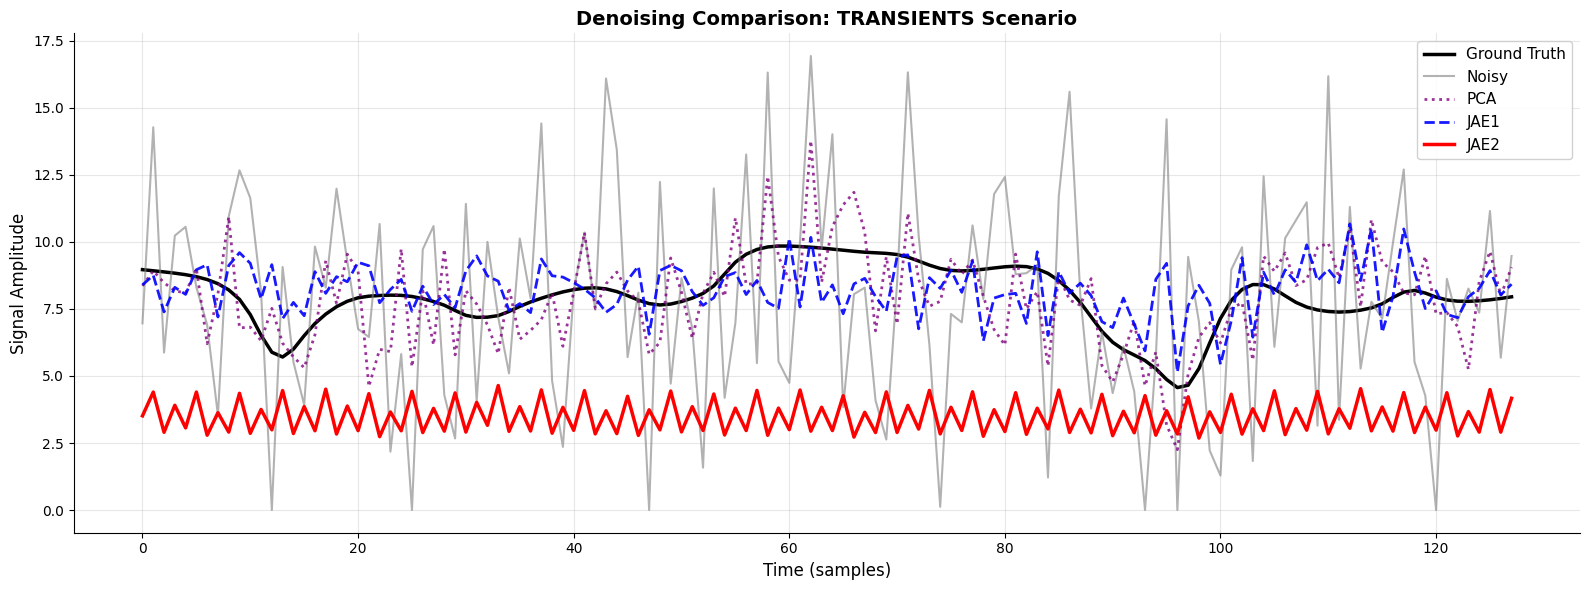

In [ ]:
# Plot denoising comparison for transients scenario
scenario = 'transients'
plot_signals(
    {
        'Ground Truth': results[scenario]['clean'],
        'Noisy': results[scenario]['noisy'],
        'PCA': results[scenario]['pca'],
        'JAE1': results[scenario]['jae1'],
        'JAE2': results[scenario]['jae2']
    },
    channel_idx=10,
    sample_idx=0,
    title=f"Denoising Comparison: TRANSIENTS Scenario",
    figsize=(16, 6)
)
plt.show()

## 6. Summary & Conclusions

### Performance Summary Table


In [ ]:
# Create summary table
print("\n" + "="*90)
print("PERFORMANCE SUMMARY: SNR (dB)")
print("="*90)
print(f"{'Scenario':<18} {'Baseline':<12} {'PCA':<12} {'JAE1':<12} {'JAE2':<12} {'Winner':<10}")
print("-"*90)

for scenario in scenarios:
    snrs = results[scenario]['snrs']
    baseline = snrs['Baseline']
    pca = snrs['PCA']
    jae1 = snrs['JAE1']
    jae2 = snrs['JAE2']
    
    best = max(pca, jae1, jae2)
    winner = "JAE2 🥇" if best == jae2 else "JAE1 🥈" if best == jae1 else "PCA 🥉"
    
    print(f"{scenario:<18} {baseline:>10.2f}  {pca:>10.2f}  {jae1:>10.2f}  {jae2:>10.2f}  {winner:<10}")

print("="*90)

# Calculate average improvements
improvements = {'PCA': [], 'JAE1': [], 'JAE2': []}
for scenario in scenarios:
    snrs = results[scenario]['snrs']
    baseline = snrs['Baseline']
    improvements['PCA'].append(snrs['PCA'] - baseline)
    improvements['JAE1'].append(snrs['JAE1'] - baseline)
    improvements['JAE2'].append(snrs['JAE2'] - baseline)

print(f"\nAverage SNR Improvement over Baseline:")
print(f"  PCA:  +{np.mean(improvements['PCA']):.2f} ± {np.std(improvements['PCA']):.2f} dB")
print(f"  JAE1: +{np.mean(improvements['JAE1']):.2f} ± {np.std(improvements['JAE1']):.2f} dB")
print(f"  JAE2: +{np.mean(improvements['JAE2']):.2f} ± {np.std(improvements['JAE2']):.2f} dB")



PERFORMANCE SUMMARY: SNR (dB)
Scenario           Baseline     PCA          JAE1         JAE2         Winner    
------------------------------------------------------------------------------------------
easy                     3.12        3.43        3.09       -0.22  PCA 🥉     
transients               6.22       15.08        7.35        3.82  PCA 🥉     
heterogeneous            8.51       15.54        9.04        7.01  PCA 🥉     
nonstationary            8.05       16.89        9.70        6.35  PCA 🥉     
high_noise              -0.76        1.69        1.23       -0.56  PCA 🥉     

Average SNR Improvement over Baseline:
  PCA:  +5.50 ± 3.49 dB
  JAE1: +1.05 ± 0.73 dB
  JAE2: +-1.75 ± 1.17 dB


### Key Findings

### Citation

```bibtex
@article{altan2021jae,
  title={Estimating the dimensionality of the manifold underlying multi-electrode neural recordings},
  author={Altan, Ege and Solla, Sara A. and Miller, Lee E. and Perreault, Eric J.},
  journal={PLOS Computational Biology},
  year={2021},
  volume={17},
  number={11},
  pages={e1008591},
  doi={10.1371/journal.pcbi.1008591}
}
```

---

**End of Demo** - The JAE package is ready to use on your neural data!
